In [1]:
# 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

In [3]:
# 2. Data Loading

In [4]:
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())

Train shape: (175341, 45)
Test shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [5]:
# 3. Data Cleaning and Feature Engineering

In [6]:
def clean_dataset(df):
    df = df.copy()
    
    # Standardise proto column
    if "proto" in df.columns:
        df["proto"] = df["proto"].astype(str).str.lower()
    
    return df

train_df = clean_dataset(train_df)
test_df  = clean_dataset(test_df)

In [7]:
def add_engineered_features(df):
    df = df.copy()

    # Safe numeric conversions if columns exist
    needed_cols = ["sbytes", "dbytes", "spkts", "dpkts", "dur"]
    for col in needed_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Total traffic features
    if {"sbytes", "dbytes"}.issubset(df.columns):
        df["total_bytes"] = df["sbytes"] + df["dbytes"]

    if {"spkts", "dpkts"}.issubset(df.columns):
        df["total_pkts"] = df["spkts"] + df["dpkts"]

    # Ratio features
    if {"sbytes", "dbytes"}.issubset(df.columns):
        df["bytes_ratio"] = df["sbytes"] / (df["dbytes"] + 1)

    if {"spkts", "dpkts"}.issubset(df.columns):
        df["pkt_ratio"] = df["spkts"] / (df["dpkts"] + 1)

    # Rate / intensity features
    if {"sbytes", "dbytes", "dur"}.issubset(df.columns):
        df["bytes_per_sec"] = (df["sbytes"] + df["dbytes"]) / (df["dur"] + 1)

    if {"spkts", "dpkts", "dur"}.issubset(df.columns):
        df["pkts_per_sec"] = (df["spkts"] + df["dpkts"]) / (df["dur"] + 1)

    # Replace infinities created by division
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

    return df

In [8]:
# 4. Initial Dataset Inspection

In [9]:
# Quick schema check
print("Columns:", len(train_df.columns))
display(pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str),
}).head(30))

Columns: 45


,column,dtype
id,id,int64
dur,dur,float64
proto,proto,object
service,service,object
state,state,object
spkts,spkts,int64
dpkts,dpkts,int64
sbytes,sbytes,int64
dbytes,dbytes,int64
rate,rate,float64


In [10]:
# Check for common target columns in UNSW-NB15
possible_targets = [c for c in ["label", "attack_cat", "class", "target", "y"] if c in train_df.columns]
print("Possible target columns found:", possible_targets)

Possible target columns found: ['label', 'attack_cat']


In [11]:
# 5. Data Analysis

In [12]:
# Missing values summary
missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:", len(missing))
display(missing.head(30))

Columns with missing values: 0


Series([], dtype: int64)

In [13]:
# Check for infinite values 
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(train_df[numeric_cols]).sum().sort_values(ascending=False)
inf_counts = inf_counts[inf_counts > 0]
print("Numeric columns with inf:", len(inf_counts))
display(inf_counts.head(30))

Numeric columns with inf: 0


Series([], dtype: int64)

In [14]:
# Class distribution (works once we know the target column)
def show_target_distribution(df, target_col: str):
    vc = df[target_col].value_counts(dropna=False)
    dist = (vc / len(df) * 100).round(2)
    out = pd.DataFrame({"count": vc, "percent": dist})
    display(out)

# If you already know your target, set it here:
TARGET_COL = "label"  # e.g. "label" for binary, or "attack_cat" for multiclass

if TARGET_COL is not None and TARGET_COL in train_df.columns:
    show_target_distribution(train_df, TARGET_COL)
else:
    print("Set TARGET_COL to view class distribution (e.g. 'label' or 'attack_cat').")

,count,percent
label,,
1,119341,68.06
0,56000,31.94


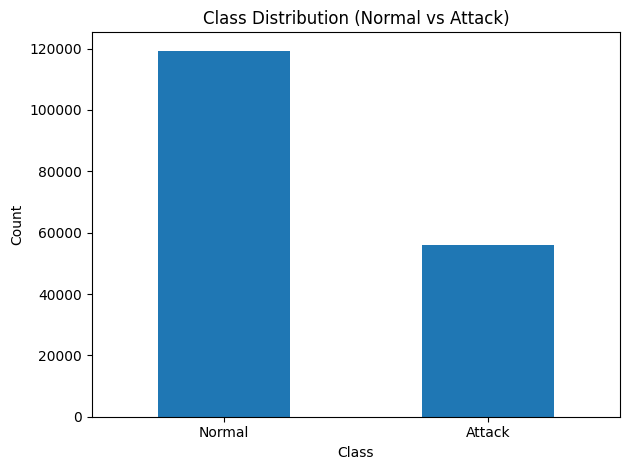

In [15]:
# Count values in the target column
counts = train_df['label'].value_counts()

# Create bar chart
plt.figure()
counts.plot(kind='bar')

# Labels and title
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Normal vs Attack)")

plt.xticks([0,1], ["Normal", "Attack"], rotation=0)

plt.tight_layout()
plt.show()

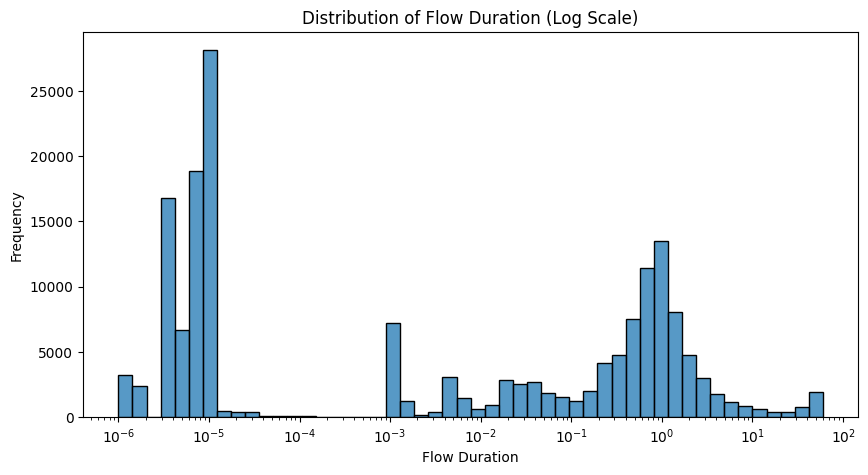

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df["dur"], bins=50, log_scale=True)

plt.title("Distribution of Flow Duration (Log Scale)")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")
plt.show()

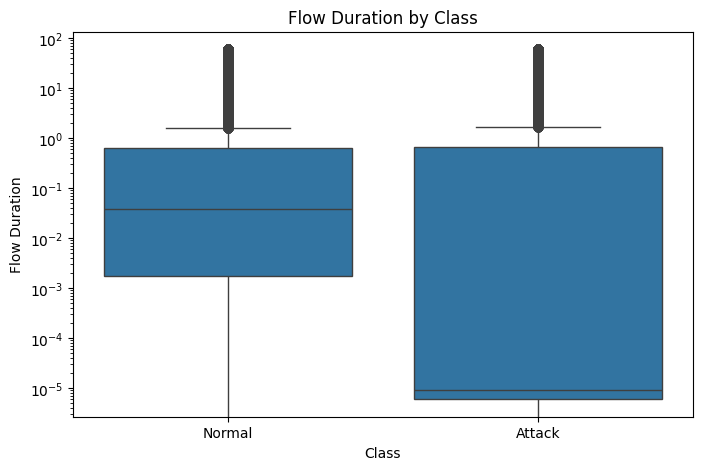

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=train_df["label"], y=train_df["dur"])
plt.yscale("log")
plt.xlabel("Class")
plt.ylabel("Flow Duration")
plt.title("Flow Duration by Class")
plt.xticks([0, 1], ["Normal", "Attack"])
plt.show()

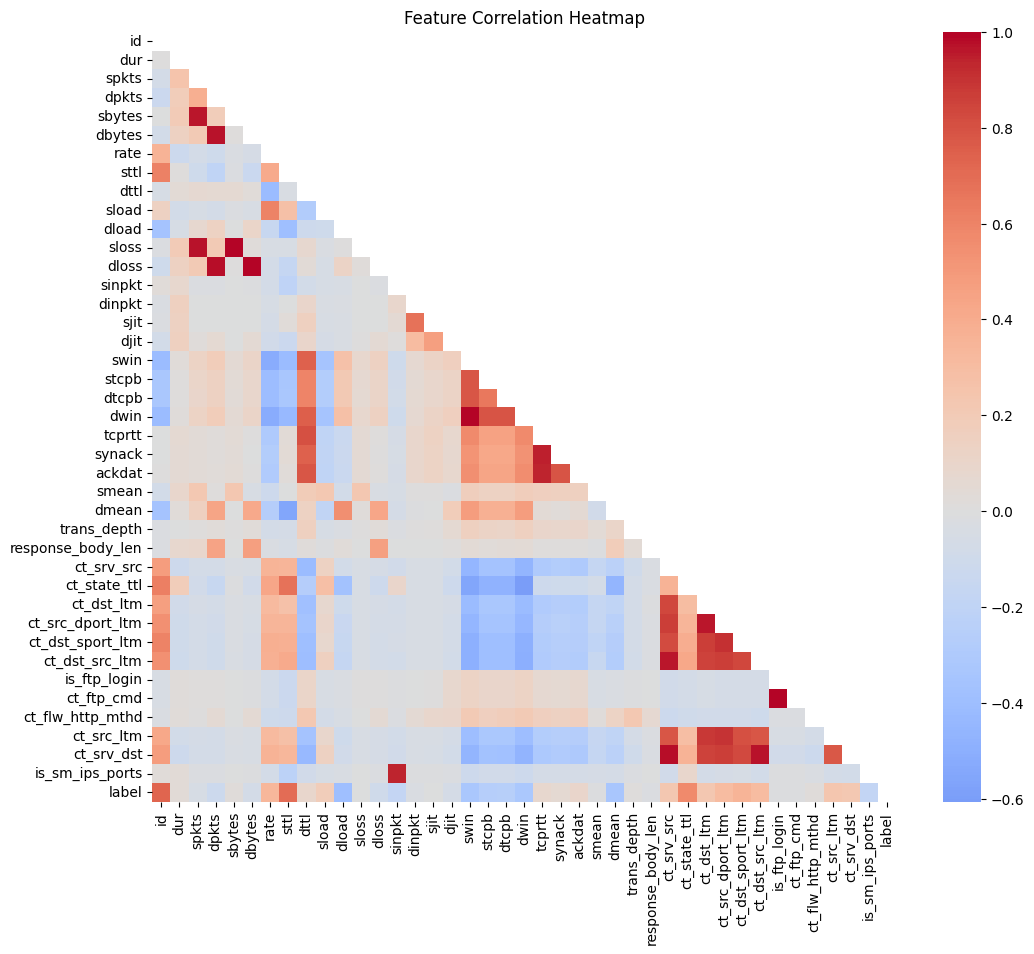

In [18]:
plt.figure(figsize=(12, 10))
corr = train_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

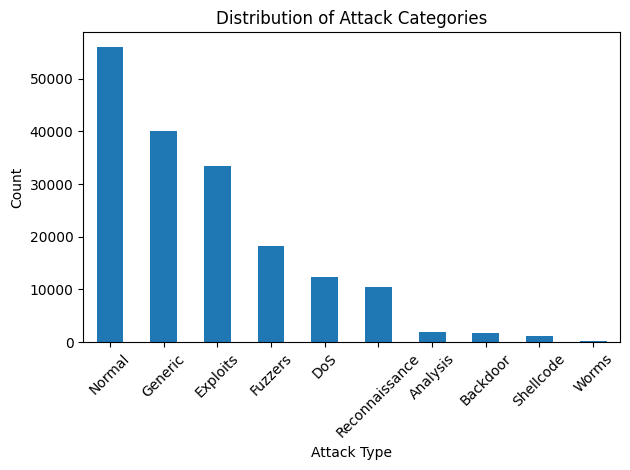

In [19]:
if "attack_cat" in train_df.columns:
    attack_counts = train_df["attack_cat"].value_counts()

    plt.figure()
    attack_counts.plot(kind="bar")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.title("Distribution of Attack Categories")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("'attack_cat' column not found.")

In [20]:
# 6. Train/ Test Feature Setup

In [21]:
TARGET_COL = "label"  # Binary classification target

# Ensure target exists BEFORE doing anything
assert TARGET_COL in train_df.columns, f"TARGET_COL '{TARGET_COL}' not found in dataset columns."

# Build drop list (ID + leakage protection)
DROP_COLS = []

if "id" in train_df.columns:
    DROP_COLS.append("id")

# Prevent label leakage
if TARGET_COL == "label" and "attack_cat" in train_df.columns:
    DROP_COLS.append("attack_cat")

print("Dropping columns:", DROP_COLS)

# Create features and labels
X = train_df.drop(columns=[TARGET_COL] + DROP_COLS)
y = train_df[TARGET_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)


Dropping columns: ['id', 'attack_cat']
X shape: (175341, 42)
y shape: (175341,)


In [22]:
TARGET_COL = "label"

DROP_COLS = []

if "id" in train_df.columns:
    DROP_COLS.append("id")

# Drop attack_cat for binary classification to prevent leakage
if TARGET_COL == "label" and "attack_cat" in train_df.columns:
    DROP_COLS.append("attack_cat")

X_train = train_df.drop(columns=DROP_COLS + [TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=DROP_COLS + [TARGET_COL])
y_test = test_df[TARGET_COL]

# Ensure train and test have the same feature columns
assert list(X_train.columns) == list(X_test.columns), "Train/test column mismatch detected."

print("Dropping columns:", DROP_COLS)
print("Train and test columns match.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Dropping columns: ['id', 'attack_cat']
Train and test columns match.
X_train shape: (175341, 42)
X_test shape: (82332, 42)


In [23]:
TARGET_COL = "label"

DROP_COLS = []

if "id" in train_df.columns:
    DROP_COLS.append("id")

# Drop attack_cat for binary classification to prevent leakage
if TARGET_COL == "label" and "attack_cat" in train_df.columns:
    DROP_COLS.append("attack_cat")

X_train = train_df.drop(columns=DROP_COLS + [TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=DROP_COLS + [TARGET_COL])
y_test = test_df[TARGET_COL]

# Ensure train and test have the same feature columns
assert list(X_train.columns) == list(X_test.columns), "Train/test column mismatch detected."

print("Dropping columns:", DROP_COLS)
print("Train and test columns match.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Dropping columns: ['id', 'attack_cat']
Train and test columns match.
X_train shape: (175341, 42)
X_test shape: (82332, 42)


In [24]:
print("Non-numeric columns in X_train:")
print(X_train.select_dtypes(exclude=[np.number]).columns.tolist())

if "attack_cat" in X_train.columns:
    raise ValueError("attack_cat is still present in X_train and must be removed.")

Non-numeric columns in X_train:
['proto', 'service', 'state']


In [25]:
# 7. Create Original and Engineered Feauture Sets

In [26]:
# New features 
# Version A: original features
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

# Version B: engineered features
train_df_eng = add_engineered_features(train_df)
test_df_eng = add_engineered_features(test_df)

# Keep drop logic aligned with your current setup
DROP_COLS_ENG = []
if "id" in train_df_eng.columns:
    DROP_COLS_ENG.append("id")
if TARGET_COL == "label" and "attack_cat" in train_df_eng.columns:
    DROP_COLS_ENG.append("attack_cat")

X_train_eng = train_df_eng.drop(columns=DROP_COLS_ENG + [TARGET_COL])
X_test_eng = test_df_eng.drop(columns=DROP_COLS_ENG + [TARGET_COL])

print("Original feature count:", X_train_orig.shape[1])
print("Engineered feature count:", X_train_eng.shape[1])
print("New engineered columns:", sorted(set(X_train_eng.columns) - set(X_train_orig.columns)))

Original feature count: 42
Engineered feature count: 48
New engineered columns: ['bytes_per_sec', 'bytes_ratio', 'pkt_ratio', 'pkts_per_sec', 'total_bytes', 'total_pkts']


In [27]:
# 8. Identify Numeric and Categorical Features

In [28]:
candidate_categorical = ["service", "state", "proto"]

# Original feature version
num_cols_orig = X_train_orig.select_dtypes(include=[np.number]).columns
X_train_orig[num_cols_orig] = X_train_orig[num_cols_orig].replace([np.inf, -np.inf], np.nan)
X_test_orig[num_cols_orig] = X_test_orig[num_cols_orig].replace([np.inf, -np.inf], np.nan)

categorical_features_orig = X_train_orig.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_features_orig = X_train_orig.select_dtypes(include=[np.number]).columns.tolist()

print("Original numeric features:", len(numeric_features_orig))
print("Original categorical features:", len(categorical_features_orig))
print("Original categorical columns:", categorical_features_orig)


# Engineered feature version
num_cols_eng = X_train_eng.select_dtypes(include=[np.number]).columns
X_train_eng[num_cols_eng] = X_train_eng[num_cols_eng].replace([np.inf, -np.inf], np.nan)
X_test_eng[num_cols_eng] = X_test_eng[num_cols_eng].replace([np.inf, -np.inf], np.nan)

categorical_features_eng = X_train_eng.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_features_eng = X_train_eng.select_dtypes(include=[np.number]).columns.tolist()

print("Engineered numeric features:", len(numeric_features_eng))
print("Engineered categorical features:", len(categorical_features_eng))
print("Engineered categorical columns:", categorical_features_eng)

Original numeric features: 39
Original categorical features: 3
Original categorical columns: ['proto', 'service', 'state']
Engineered numeric features: 45
Engineered categorical features: 3
Engineered categorical columns: ['proto', 'service', 'state']


In [29]:
# 9. Build Preprocessing Pipelines

In [30]:
numeric_transformer_orig = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_orig = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_orig = ColumnTransformer(transformers=[
    ("num", numeric_transformer_orig, numeric_features_orig),
    ("cat", categorical_transformer_orig, categorical_features_orig)
])


numeric_transformer_eng = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_eng = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_eng = ColumnTransformer(transformers=[
    ("num", numeric_transformer_eng, numeric_features_eng),
    ("cat", categorical_transformer_eng, categorical_features_eng)
])
print("Preprocessor built.")

Preprocessor built.


In [31]:
# 10. Baseline Model - Logistic Regression

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    # ADDED: class_weight="balanced" to handle the 68/32 imbalance
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")) 
])

baseline_scores = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("Baseline (Logistic Regression) CV Results:")
for metric in baseline_scores:
    if "test" in metric:
        print(f"{metric}: {baseline_scores[metric].mean():.4f} (+/- {baseline_scores[metric].std():.4f})")

Baseline (Logistic Regression) CV Results:
test_accuracy: 0.9326 (+/- 0.0017)
test_precision: 0.9494 (+/- 0.0008)
test_recall: 0.9517 (+/- 0.0024)
test_f1: 0.9505 (+/- 0.0013)
test_roc_auc: 0.9844 (+/- 0.0005)


In [33]:
baseline_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        baseline_scores["test_accuracy"].mean(),
        baseline_scores["test_precision"].mean(),
        baseline_scores["test_recall"].mean(),
        baseline_scores["test_f1"].mean(),
        baseline_scores["test_roc_auc"].mean()
    ],
    "Std": [
        baseline_scores["test_accuracy"].std(),
        baseline_scores["test_precision"].std(),
        baseline_scores["test_recall"].std(),
        baseline_scores["test_f1"].std(),
        baseline_scores["test_roc_auc"].std()
    ]
})

baseline_cv_summary

,Metric,Mean,Std
0,Accuracy,0.932583,0.001737
1,Precision,0.949371,0.000786
2,Recall,0.951701,0.002366
3,F1,0.950533,0.001322
4,ROC-AUC,0.984356,0.000516


In [34]:
baseline_pipeline.fit(X_train, y_train)

base_pred = baseline_pipeline.predict(X_test)
base_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Baseline Test Performance")
print(classification_report(y_test, base_pred))
print("ROC-AUC:", roc_auc_score(y_test, base_proba))

Baseline Test Performance
              precision    recall  f1-score   support

           0       0.89      0.72      0.80     37000
           1       0.80      0.93      0.86     45332

    accuracy                           0.84     82332
   macro avg       0.85      0.83      0.83     82332
weighted avg       0.84      0.84      0.83     82332

ROC-AUC: 0.9559491362226075


In [35]:
# 11. Random Forest Model

In [36]:
# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Build pipeline (preprocessing + model)
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced", # ADDED: class_weight for imbalance
        n_jobs=-1
    ))
])

# Cross-validation
rf_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("Random Forest CV Results:")
for metric in rf_scores:
    if "test" in metric:
        print(f"{metric}: {rf_scores[metric].mean():.4f} (+/- {rf_scores[metric].std():.4f})")

Random Forest CV Results:
test_accuracy: 0.9589 (+/- 0.0010)
test_precision: 0.9619 (+/- 0.0009)
test_recall: 0.9783 (+/- 0.0010)
test_f1: 0.9700 (+/- 0.0007)
test_roc_auc: 0.9936 (+/- 0.0003)


In [37]:
rf_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        rf_scores["test_accuracy"].mean(),
        rf_scores["test_precision"].mean(),
        rf_scores["test_recall"].mean(),
        rf_scores["test_f1"].mean(),
        rf_scores["test_roc_auc"].mean()
    ],
    "Std": [
        rf_scores["test_accuracy"].std(),
        rf_scores["test_precision"].std(),
        rf_scores["test_recall"].std(),
        rf_scores["test_f1"].std(),
        rf_scores["test_roc_auc"].std()
    ]
})

rf_cv_summary

,Metric,Mean,Std
0,Accuracy,0.958852,0.001013
1,Precision,0.961881,0.000874
2,Recall,0.978314,0.001022
3,F1,0.970027,0.000740
4,ROC-AUC,0.993633,0.000293


In [38]:
rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Test Performance")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest Test Performance
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     37000
           1       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332

ROC-AUC: 0.9793045965978332


In [39]:
# 12. XGBoost Model

In [40]:
# Calculate scale_pos_weight for XGBoost
class_counts = y_train.value_counts().sort_index()

if len(class_counts) != 2:
    raise ValueError("XGBoost scale_pos_weight calculation expects binary labels.")

negative_count = class_counts.iloc[0]
positive_count = class_counts.iloc[1]
scale_weight = negative_count / positive_count

print("Class counts:", class_counts.to_dict())
print("scale_pos_weight:", round(scale_weight, 4))

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_scores = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("XGBoost CV Results:")
for metric in xgb_scores:
    if "test" in metric:
        print(f"{metric}: {xgb_scores[metric].mean():.4f} (+/- {xgb_scores[metric].std():.4f})")

Class counts: {0: 56000, 1: 119341}
scale_pos_weight: 0.4692
XGBoost CV Results:
test_accuracy: 0.9460 (+/- 0.0016)
test_precision: 0.9784 (+/- 0.0013)
test_recall: 0.9414 (+/- 0.0014)
test_f1: 0.9595 (+/- 0.0012)
test_roc_auc: 0.9925 (+/- 0.0004)


In [41]:
xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost Test Performance")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

XGBoost Test Performance
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     37000
           1       0.89      0.96      0.92     45332

    accuracy                           0.91     82332
   macro avg       0.92      0.91      0.91     82332
weighted avg       0.92      0.91      0.91     82332

ROC-AUC: 0.9849099612826451


In [42]:
xgb_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        xgb_scores["test_accuracy"].mean(),
        xgb_scores["test_precision"].mean(),
        xgb_scores["test_recall"].mean(),
        xgb_scores["test_f1"].mean(),
        xgb_scores["test_roc_auc"].mean()
    ],
    "Std": [
        xgb_scores["test_accuracy"].std(),
        xgb_scores["test_precision"].std(),
        xgb_scores["test_recall"].std(),
        xgb_scores["test_f1"].std(),
        xgb_scores["test_roc_auc"].std()
    ]
})

xgb_cv_summary

,Metric,Mean,Std
0,Accuracy,0.945957,0.001639
1,Precision,0.978403,0.001341
2,Recall,0.941378,0.001428
3,F1,0.959533,0.001231
4,ROC-AUC,0.992468,0.000399


In [43]:
# 13. Untuned Model Comparison

In [44]:
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, base_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, base_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, xgb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, base_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, xgb_pred, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, base_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, xgb_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, base_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})

metrics_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.835738,0.802472,0.930777,0.861876,0.955949
1,Random Forest,0.871241,0.817451,0.986433,0.894027,0.979305
2,XGBoost,0.913812,0.889432,0.963205,0.924850,0.984910


In [ ]:
# Plot ROC Curves
base_fpr, base_tpr, _ = roc_curve(y_test, base_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 6))
plt.plot(base_fpr, base_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, base_proba):.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
plot_df = metrics_df.set_index("Model")
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Random Forest vs XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# 14. Hyperparameter Tuning - Random Forest

In [ ]:
# Hyperparameter Tuning - Random Forest

rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 400, 600],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ['sqrt', 'log2'] # Adding features to the search
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF ROC-AUC:", rf_search.best_score_)
print("Best RF params:", rf_search.best_params_)

In [ ]:
rf_best = rf_search.best_estimator_

rf_pred_tuned = rf_best.predict(X_test)
rf_proba_tuned = rf_best.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Test Performance")
print(classification_report(y_test, rf_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba_tuned))

In [ ]:
# 15. Hyperparameter Tuning - XGBoost Tuning

In [ ]:
# 7. Hyperparameter Tuning - XGBoost

xgb_base = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_weight
    ))
])

xgb_param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 6, 8],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB ROC-AUC:", xgb_search.best_score_)
print("Best XGB params:", xgb_search.best_params_)

In [ ]:
xgb_search_f1 = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search_f1.fit(X_train, y_train)

print("Best XGB F1:", xgb_search_f1.best_score_)
print("Best XGB params (F1):", xgb_search_f1.best_params_)

In [ ]:
# Evaluate the F1-tuned XGBoost model
xgb_best = xgb_search_f1.best_estimator_

xgb_pred_tuned = xgb_best.predict(X_test)
xgb_proba_tuned = xgb_best.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Test Performance")
print(classification_report(y_test, xgb_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba_tuned))

In [ ]:
# 16. Tuned XGBoost Threshold Analysis

In [ ]:
xgb_proba_tuned = xgb_best.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6]:
    preds = (xgb_proba_tuned >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print("Precision:", precision_score(y_test, preds, zero_division=0))
    print("Recall:", recall_score(y_test, preds, zero_division=0))
    print("F1:", f1_score(y_test, preds, zero_division=0))
    print("-" * 30)

In [ ]:
tuned_results_df = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred_tuned),
        accuracy_score(y_test, xgb_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, rf_pred_tuned, zero_division=0),
        precision_score(y_test, xgb_pred_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rf_pred_tuned, zero_division=0),
        recall_score(y_test, xgb_pred_tuned, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, rf_pred_tuned, zero_division=0),
        f1_score(y_test, xgb_pred_tuned, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_proba_tuned),
        roc_auc_score(y_test, xgb_proba_tuned)
    ]
})

tuned_results_df

In [ ]:
comparison_all = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, base_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_pred_tuned),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, xgb_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, base_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_pred_tuned),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, base_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_pred_tuned),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, xgb_pred_tuned)
    ],
    "F1-score": [
        f1_score(y_test, base_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_pred_tuned),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, xgb_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, base_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, rf_proba_tuned),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, xgb_proba_tuned)
    ]
})

comparison_all.sort_values(by="F1-score", ascending=False)

In [ ]:
# 17. Original vs Engineered Feature Comparison

In [ ]:
# Compare XGBoost on original vs engineered features

# Original-feature XGBoost
xgb_orig_compare = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_orig_compare.fit(X_train_orig, y_train)
xgb_orig_pred = xgb_orig_compare.predict(X_test_orig)
xgb_orig_proba = xgb_orig_compare.predict_proba(X_test_orig)[:, 1]


# Engineered-feature XGBoost
xgb_eng_compare = Pipeline(steps=[
    ("preprocessor", preprocessor_eng),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_eng_compare.fit(X_train_eng, y_train)
xgb_eng_pred = xgb_eng_compare.predict(X_test_eng)
xgb_eng_proba = xgb_eng_compare.predict_proba(X_test_eng)[:, 1]

feature_test_df = pd.DataFrame({
    "Feature Set": ["Original", "Engineered"],
    "Accuracy": [
        accuracy_score(y_test, xgb_orig_pred),
        accuracy_score(y_test, xgb_eng_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_orig_pred, zero_division=0),
        precision_score(y_test, xgb_eng_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, xgb_orig_pred, zero_division=0),
        recall_score(y_test, xgb_eng_pred, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, xgb_orig_pred, zero_division=0),
        f1_score(y_test, xgb_eng_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, xgb_orig_proba),
        roc_auc_score(y_test, xgb_eng_proba)
    ]
})

feature_test_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tuned Random Forest
cm_rf_tuned = confusion_matrix(y_test, rf_pred_tuned)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=["Benign", "Attack"])
# Added values_format='d' to ensure integers are shown without scientific notation
disp_rf_tuned.plot(ax=axes[0], colorbar=False, values_format='d') 
axes[0].set_title("Tuned Random Forest Confusion Matrix")

# Tuned XGBoost
cm_xgb_tuned = confusion_matrix(y_test, xgb_pred_tuned)
disp_xgb_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_tuned, display_labels=["Benign", "Attack"])
# Added values_format='d' here as well
disp_xgb_tuned.plot(ax=axes[1], colorbar=False, values_format='d')
axes[1].set_title("Tuned XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# 18A. Imbalance handling comparison

In [ ]:
xgb_unweighted = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_weighted = Pipeline(steps=[
    ("preprocessor", preprocessor_orig),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_unweighted.fit(X_train, y_train)
xgb_weighted.fit(X_train, y_train)

pred_unweighted = xgb_unweighted.predict(X_test)
pred_weighted = xgb_weighted.predict(X_test)

imbalance_df = pd.DataFrame({
    "Model": ["Unweighted", "Weighted"],
    "Accuracy": [
        accuracy_score(y_test, pred_unweighted),
        accuracy_score(y_test, pred_weighted)
    ],
    "Precision": [
        precision_score(y_test, pred_unweighted, zero_division=0),
        precision_score(y_test, pred_weighted, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, pred_unweighted, zero_division=0),
        recall_score(y_test, pred_weighted, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, pred_unweighted, zero_division=0),
        f1_score(y_test, pred_weighted, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, xgb_unweighted.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb_weighted.predict_proba(X_test)[:, 1])
    ]
})

imbalance_df


In [ ]:
# 18B. Overfitting check

def get_metrics_df(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)
    train_proba = model.predict_proba(X_train_data)[:, 1]
    test_proba = model.predict_proba(X_test_data)[:, 1]
    return pd.DataFrame({
        "Model": [model_name, model_name],
        "Dataset": ["Train", "Test"],
        "Accuracy": [
            accuracy_score(y_train_data, train_pred),
            accuracy_score(y_test_data, test_pred)
        ],
        "Precision": [
            precision_score(y_train_data, train_pred, zero_division=0),
            precision_score(y_test_data, test_pred, zero_division=0)
        ],
        "Recall": [
            recall_score(y_train_data, train_pred, zero_division=0),
            recall_score(y_test_data, test_pred, zero_division=0)
        ],
        "F1-score": [
            f1_score(y_train_data, train_pred, zero_division=0),
            f1_score(y_test_data, test_pred, zero_division=0)
        ],
        "ROC-AUC": [
            roc_auc_score(y_train_data, train_proba),
            roc_auc_score(y_test_data, test_proba)
        ]
    })

overfitting_df = pd.concat([
    get_metrics_df(xgb_pipeline, X_train, y_train, X_test, y_test, "XGBoost"),
    get_metrics_df(xgb_best, X_train, y_train, X_test, y_test, "Tuned XGBoost")
], ignore_index=True)

overfitting_df


In [ ]:
# 18C. Overfitting gap summary

overfitting_gap_df = overfitting_df.pivot(index="Model", columns="Dataset", values="F1-score").reset_index()
overfitting_gap_df["F1 Gap (Train - Test)"] = overfitting_gap_df["Train"] - overfitting_gap_df["Test"]
overfitting_gap_df.sort_values(by="F1 Gap (Train - Test)", ascending=False)


In [ ]:
# 18D. Load CIC dataset and map basic + expanded shared features

cic_df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Clean column names
cic_df.columns = cic_df.columns.str.strip()

print("CIC columns after stripping:")
print(cic_df.columns.tolist())

label_col = "Label"
cic_y = (cic_df[label_col].astype(str).str.upper().str.strip() != "BENIGN").astype(int)

# Basic shared features
cic_X_basic = pd.DataFrame({
    "dur": pd.to_numeric(cic_df["Flow Duration"], errors="coerce"),
    "spkts": pd.to_numeric(cic_df["Total Fwd Packets"], errors="coerce"),
    "dpkts": pd.to_numeric(cic_df["Total Backward Packets"], errors="coerce"),
    "sbytes": pd.to_numeric(cic_df["Total Length of Fwd Packets"], errors="coerce"),
    "dbytes": pd.to_numeric(cic_df["Total Length of Bwd Packets"], errors="coerce")
})

# Expanded shared features
cic_X_expanded = pd.DataFrame({
    "dur": pd.to_numeric(cic_df["Flow Duration"], errors="coerce"),
    "spkts": pd.to_numeric(cic_df["Total Fwd Packets"], errors="coerce"),
    "dpkts": pd.to_numeric(cic_df["Total Backward Packets"], errors="coerce"),
    "sbytes": pd.to_numeric(cic_df["Total Length of Fwd Packets"], errors="coerce"),
    "dbytes": pd.to_numeric(cic_df["Total Length of Bwd Packets"], errors="coerce"),
    "rate": pd.to_numeric(cic_df["Flow Packets/s"], errors="coerce"),
    "smean": pd.to_numeric(cic_df["Avg Fwd Segment Size"], errors="coerce"),
    "dmean": pd.to_numeric(cic_df["Avg Bwd Segment Size"], errors="coerce"),
    "pkt_len_mean": pd.to_numeric(cic_df["Packet Length Mean"], errors="coerce"),
    "pkt_len_std": pd.to_numeric(cic_df["Packet Length Std"], errors="coerce"),
    "flow_iat_mean": pd.to_numeric(cic_df["Flow IAT Mean"], errors="coerce"),
    "flow_iat_std": pd.to_numeric(cic_df["Flow IAT Std"], errors="coerce")
})

cic_X_basic = cic_X_basic.replace([np.inf, -np.inf], np.nan)
cic_X_expanded = cic_X_expanded.replace([np.inf, -np.inf], np.nan)

print("CIC label distribution:")
print(cic_y.value_counts())


In [ ]:
# 18E. Train basic and expanded shared-feature XGBoost models for external validation

basic_shared_features = ["dur", "spkts", "dpkts", "sbytes", "dbytes"]
expanded_shared_features = [
    "dur", "spkts", "dpkts", "sbytes", "dbytes",
    "rate", "smean", "dmean", "pkt_len_mean", "pkt_len_std",
    "flow_iat_mean", "flow_iat_std"
]

# Matching UNSW feature sets
X_train_basic = X_train[basic_shared_features].copy()
X_test_basic = X_test[basic_shared_features].copy()

X_train_expanded = pd.DataFrame({
    "dur": X_train["dur"],
    "spkts": X_train["spkts"],
    "dpkts": X_train["dpkts"],
    "sbytes": X_train["sbytes"],
    "dbytes": X_train["dbytes"],
    "rate": X_train["rate"],
    "smean": X_train["smean"],
    "dmean": X_train["dmean"],
    "pkt_len_mean": X_train["smean"] + X_train["dmean"],
    "pkt_len_std": X_train["sjit"],
    "flow_iat_mean": X_train["sinpkt"],
    "flow_iat_std": X_train["sjit"]
})

X_test_expanded = pd.DataFrame({
    "dur": X_test["dur"],
    "spkts": X_test["spkts"],
    "dpkts": X_test["dpkts"],
    "sbytes": X_test["sbytes"],
    "dbytes": X_test["dbytes"],
    "rate": X_test["rate"],
    "smean": X_test["smean"],
    "dmean": X_test["dmean"],
    "pkt_len_mean": X_test["smean"] + X_test["dmean"],
    "pkt_len_std": X_test["sjit"],
    "flow_iat_mean": X_test["sinpkt"],
    "flow_iat_std": X_test["sjit"]
})

for df in [X_train_basic, X_test_basic, X_train_expanded, X_test_expanded]:
    df[:] = df.apply(pd.to_numeric, errors="coerce")
    df[:] = df.replace([np.inf, -np.inf], np.nan)

basic_shared_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

expanded_shared_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

basic_shared_model.fit(X_train_basic, y_train)
expanded_shared_model.fit(X_train_expanded, y_train)

unsw_basic_pred = basic_shared_model.predict(X_test_basic)
unsw_basic_proba = basic_shared_model.predict_proba(X_test_basic)[:, 1]
unsw_expanded_pred = expanded_shared_model.predict(X_test_expanded)
unsw_expanded_proba = expanded_shared_model.predict_proba(X_test_expanded)[:, 1]

cic_basic_pred = basic_shared_model.predict(cic_X_basic)
cic_basic_proba = basic_shared_model.predict_proba(cic_X_basic)[:, 1]
cic_expanded_pred = expanded_shared_model.predict(cic_X_expanded)
cic_expanded_proba = expanded_shared_model.predict_proba(cic_X_expanded)[:, 1]


In [ ]:
# 18F. Compare basic vs expanded shared-feature external validation

external_comparison_df = pd.DataFrame({
    "Feature Set": ["Basic Shared Features", "Expanded Shared Features"],
    "UNSW Test F1": [
        f1_score(y_test, unsw_basic_pred, zero_division=0),
        f1_score(y_test, unsw_expanded_pred, zero_division=0)
    ],
    "CIC External F1": [
        f1_score(cic_y, cic_basic_pred, zero_division=0),
        f1_score(cic_y, cic_expanded_pred, zero_division=0)
    ],
    "UNSW Test ROC-AUC": [
        roc_auc_score(y_test, unsw_basic_proba),
        roc_auc_score(y_test, unsw_expanded_proba)
    ],
    "CIC External ROC-AUC": [
        roc_auc_score(cic_y, cic_basic_proba),
        roc_auc_score(cic_y, cic_expanded_proba)
    ]
})

external_comparison_df


In [ ]:
# 18G. Expanded shared-feature external validation results

external_validation_df = pd.DataFrame({
    "Dataset": ["UNSW Test (Expanded Shared Features)", "CIC External"],
    "Accuracy": [
        accuracy_score(y_test, unsw_expanded_pred),
        accuracy_score(cic_y, cic_expanded_pred)
    ],
    "Precision": [
        precision_score(y_test, unsw_expanded_pred, zero_division=0),
        precision_score(cic_y, cic_expanded_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, unsw_expanded_pred, zero_division=0),
        recall_score(cic_y, cic_expanded_pred, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, unsw_expanded_pred, zero_division=0),
        f1_score(cic_y, cic_expanded_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, unsw_expanded_proba),
        roc_auc_score(cic_y, cic_expanded_proba)
    ]
})

external_validation_df


In [ ]:
# 18H. Confusion matrices for expanded shared-feature external validation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, unsw_expanded_pred, ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("UNSW Test - Shared Feature Model")

ConfusionMatrixDisplay.from_predictions(
    cic_y, cic_expanded_pred, ax=axes[1], cmap="Blues", values_format="d"
)
axes[1].set_title("CIC External - Shared Feature Model")

plt.tight_layout()
plt.show()


In [ ]:
# 18I. Threshold tuning on CIC for expanded shared-feature model

cic_thresholds = np.linspace(0.1, 0.9, 9)
cic_threshold_results = []

for t in cic_thresholds:
    preds = (cic_expanded_proba >= t).astype(int)
    cic_threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(cic_y, preds, zero_division=0),
        "Recall": recall_score(cic_y, preds, zero_division=0),
        "F1-score": f1_score(cic_y, preds, zero_division=0)
    })

cic_threshold_df = pd.DataFrame(cic_threshold_results)
cic_threshold_df


In [ ]:
# 18J. CIC threshold performance plot

cic_threshold_plot_df = cic_threshold_df.set_index("Threshold")

plt.figure(figsize=(8, 5))
cic_threshold_plot_df.plot(marker="o")
plt.title("CIC External Performance Across Decision Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.show()

best_cic_threshold_row = cic_threshold_df.loc[cic_threshold_df["F1-score"].idxmax()]
best_cic_threshold_row


In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# Save the best-performing model and useful metadata
# Update best_model if another model outperforms tuned XGBoost.
best_model = xgb_best

joblib.dump(best_model, "best_ids_model.joblib")
joblib.dump({
    "target_col": TARGET_COL,
    "categorical_features_orig": categorical_features_orig,
    "numeric_features_orig": numeric_features_orig,
    "categorical_features_eng": categorical_features_eng,
    "numeric_features_eng": numeric_features_eng,
    "random_state": RANDOM_STATE
}, "best_ids_model_metadata.joblib")

print("Saved model to best_ids_model.joblib")
print("Saved metadata to best_ids_model_metadata.joblib")